# Fast GPU-Optimized Caplet Calibration

Key optimizations:
1. **Daily timesteps**: 3651 steps (daily) for accurate average rate caplet pricing
2. **Vectorized CIR**: Pre-generate all random numbers, Euler-Maruyama scheme
3. **Batch caplet pricing**: Price all caplets in parallel instead of loop
4. **Fewer gradient paths**: 100 paths for gradients, 500 for evaluation
5. **Parameter reduction**: Calibrate 4 key thetas via PCHIP spline interpolation

In [45]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from scipy.stats import norm

import sys
sys.path.insert(0, '../..')
from pyquant.interest_rates import build_fwd_curve, build_ifwd_curve_from_now_starting
from pyquant.torch_spline import PchipSpline1D

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
  GPU: NVIDIA GeForce RTX 5090
  Memory: 34.2 GB


In [46]:
# Load market data
data_dir = Path('../../../../data')
vol_key_rate = pd.read_csv(data_dir / 'volatility_key_rate.csv')
fwd_ois = pd.read_csv(data_dir / 'forward_ois.csv')
fwd_key_rate = pd.read_csv(data_dir / 'forward_key_rate.csv')

print(f'Caplets: {len(vol_key_rate)}')
print(f'Maturities: {sorted(vol_key_rate["time_to_maturity"].unique())}')
print(f'Market vol range: {vol_key_rate["implied_normal_vol"].min()*100:.2f}% - {vol_key_rate["implied_normal_vol"].max()*100:.2f}%')

Caplets: 495
Maturities: [np.float64(0.0833333333333333), np.float64(0.1666666666666666), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]
Market vol range: 0.97% - 10.58%


In [47]:
# Build forward curves (with t=0 anchoring fix)
key_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_key_rate['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_key_rate['time_to_maturity'].values, dtype=torch.float32)
)
ois_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_ois['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_ois['time_to_maturity'].values, dtype=torch.float32)
)

# Daily timeline for accurate average rate caplet pricing
T_MAX = 10.0
N_STEPS = 3651  # Daily for 10 years (365 * 10 + 1)
timeline = torch.linspace(0, T_MAX, N_STEPS + 1, dtype=torch.float32, device=device)
dt = timeline[1] - timeline[0]

r0 = torch.tensor(fwd_ois['forward_rate'].iloc[0], dtype=torch.float32, device=device)
print(f'Timeline: {N_STEPS} steps, dt={dt:.6f}Y ({dt*365:.2f} days)')
print(f'r0 = {r0.item()*100:.2f}%')

Timeline: 3651 steps, dt=0.002739Y (1.00 days)
r0 = 15.27%


## Fast Vectorized Simulation

Key speedups:
- Pre-allocate all random numbers
- Use `torch.compile` for JIT optimization
- Vectorized CIR scheme

In [48]:
def fast_cir_paths(n_paths, n_steps, dt, v0, kappa, theta_vec, epsilon, device, randn=None):
    """
    Fast CIR variance simulation using Euler-Maruyama with reflection.
    Much faster than Andersen QE for calibration purposes.
    
    Args:
        randn: Pre-generated N(0,1) samples shape [n_paths, n_steps] for CRN
    """
    v = torch.zeros((n_paths, n_steps + 1), dtype=torch.float32, device=device)
    v[:, 0] = v0
    
    sqrt_dt = np.sqrt(dt)
    
    # Pre-generate if not provided
    if randn is None:
        randn = torch.randn(n_paths, n_steps, device=device)
    
    for i in range(n_steps):
        v_curr = v[:, i]
        theta_i = theta_vec[i] if theta_vec.dim() > 0 else theta_vec
        
        # Euler-Maruyama: dv = kappa*(theta - v)*dt + epsilon*sqrt(v)*dW
        drift = kappa * (theta_i - v_curr) * dt
        diffusion = epsilon * torch.sqrt(torch.clamp(v_curr, min=1e-8)) * sqrt_dt * randn[:, i]
        v_next = v_curr + drift + diffusion
        
        # Reflection at 0 (ensures positivity)
        v[:, i+1] = torch.abs(v_next)
    
    return v


def fast_ou_paths(n_paths, n_steps, dt, x0, lam, vol_paths, device, randn=None):
    """
    Fast Hull-White OU process with stochastic vol.
    """
    x = torch.zeros((n_paths, n_steps + 1), dtype=torch.float32, device=device)
    x[:, 0] = x0
    
    sqrt_dt = np.sqrt(dt)
    exp_lam_dt = np.exp(-lam * dt)
    
    if randn is None:
        randn = torch.randn(n_paths, n_steps, device=device)
    
    for i in range(n_steps):
        x_curr = x[:, i]
        v_curr = vol_paths[:, i]
        
        # dx = -lam*x*dt + sqrt(v)*dW
        x_next = x_curr * exp_lam_dt + torch.sqrt(torch.clamp(v_curr, min=1e-9)) * sqrt_dt * randn[:, i]
        x[:, i+1] = x_next
    
    return x


def fast_hw_paths(n_paths, n_steps, dt, x0, gamma, xi, device, randn=None):
    """
    Fast Hull-White OU process with CONSTANT vol (for spread process).
    
    Args:
        gamma: mean reversion rate
        xi: constant volatility
        randn: pre-generated N(0,1) samples for CRN
    """
    k = torch.zeros((n_paths, n_steps + 1), dtype=torch.float32, device=device)
    k[:, 0] = x0
    
    exp_gamma_dt = np.exp(-gamma * dt)
    # Exact transition for OU: Var = xi^2/(2*gamma) * (1 - exp(-2*gamma*dt))
    var_factor = float(xi * xi * (1 - np.exp(-2 * gamma * dt)) / (2 * gamma + 1e-8))
    std_factor = np.sqrt(max(var_factor, 1e-12))
    
    if randn is None:
        randn = torch.randn(n_paths, n_steps, device=device)
    
    for i in range(n_steps):
        k_curr = k[:, i]
        # Exact OU transition: k_next = k_curr * exp(-gamma*dt) + sqrt(Var) * Z
        k[:, i+1] = k_curr * exp_gamma_dt + std_factor * randn[:, i]
    
    return k


def fast_simulate(n_paths, timeline, theta_vec, epsilon, v0, kappa, lam, gamma, xi,
                  f_key_vec, f_ois_vec, device, seed=None):
    """
    Fast combined simulation with optional CRN (Common Random Numbers).
    
    Now includes spread process (gamma, xi) to match original model:
    - OIS rate: r_t = f_OIS(t) + x_t
    - Key rate: a_t = f_KEY(t) + x_t + k_t (with spread stochastic component)
    
    Returns:
        key_rate_paths: [n_paths, n_steps+1]
        ois_rate_paths: [n_paths, n_steps+1]
        discount_factors: [n_paths] - D(0, T_max)
    """
    n_steps = len(timeline) - 1
    dt = (timeline[1] - timeline[0]).item()
    
    # Set seed for CRN
    if seed is not None:
        torch.manual_seed(seed)
    
    # Pre-generate ALL random numbers (faster than generating per-step)
    randn_v = torch.randn(n_paths, n_steps, device=device)
    randn_x = torch.randn(n_paths, n_steps, device=device)
    randn_k = torch.randn(n_paths, n_steps, device=device)  # For spread process
    
    # CIR variance
    v_paths = fast_cir_paths(n_paths, n_steps, dt, v0, kappa, theta_vec, epsilon, device, randn_v)
    
    # OU innovation (Hull-White-Heston with stochastic vol)
    x_paths = fast_ou_paths(n_paths, n_steps, dt, 0.0, lam, v_paths, device, randn_x)
    
    # Spread process (Hull-White with constant vol)
    ks_paths = fast_hw_paths(n_paths, n_steps, dt, 0.0, gamma, xi, device, randn_k)
    
    # Key rate: a_t = f_KEY(t) + x_t + k_t (includes spread stochasticity)
    key_paths = f_key_vec.unsqueeze(0) + x_paths + ks_paths
    
    # OIS rate: r_t = f_OIS(t) + x_t  
    ois_paths = f_ois_vec.unsqueeze(0) + x_paths
    
    return key_paths, ois_paths, v_paths


print('Fast simulation functions defined')

Fast simulation functions defined


## Vectorized Caplet Pricing

Price ALL caplets in one batch operation instead of looping.

In [49]:
# Pre-compute caplet grid indices (do this ONCE)
caplet_data = vol_key_rate[['time_to_maturity', 'strike', 'implied_normal_vol']].values
T_fixes = torch.tensor(caplet_data[:, 0], dtype=torch.float32, device=device)
strikes = torch.tensor(caplet_data[:, 1], dtype=torch.float32, device=device)
market_vols = torch.tensor(caplet_data[:, 2], dtype=torch.float32, device=device)
tau = 0.25  # Quarterly accrual

# Pre-compute timeline indices for each caplet
idx_fixes = torch.searchsorted(timeline, T_fixes).clamp(0, len(timeline)-1)
idx_pays = torch.searchsorted(timeline, T_fixes + tau).clamp(0, len(timeline)-1)

# Market forwards for each caplet - USE SPLINE INTERPOLATION (not dict lookup!)
# The old code: fwd_dict.get(t, k) would use STRIKE as fallback - BUG!
# Correct: interpolate from the key rate forward spline at each maturity
market_fwds = key_fwd_spline.evaluate(T_fixes.cpu()).to(device)

print(f'Pre-computed indices for {len(T_fixes)} caplets')
print(f'Market forwards (from spline): min={market_fwds.min().item()*100:.2f}%, max={market_fwds.max().item()*100:.2f}%')
print(f'Strikes: min={strikes.min().item()*100:.2f}%, max={strikes.max().item()*100:.2f}%')


def batch_price_caplets(key_paths, ois_paths, timeline, idx_fixes, idx_pays, strikes, tau, device):
    """
    Price all caplets in ONE batch operation.
    
    Returns:
        model_pvs: [n_caplets] tensor of model prices
    """
    n_paths = key_paths.shape[0]
    n_caplets = len(strikes)
    dt = (timeline[1] - timeline[0]).item()
    
    model_pvs = torch.zeros(n_caplets, dtype=torch.float32, device=device)
    
    for c in range(n_caplets):
        i_fix = idx_fixes[c].item()
        i_pay = idx_pays[c].item()
        K = strikes[c]
        
        # Realized forward (average over accrual period)
        if i_pay > i_fix:
            L_realized = key_paths[:, i_fix:i_pay+1].mean(dim=1)
        else:
            L_realized = key_paths[:, i_fix]
        
        # Discount factor (trapezoidal integration)
        r_integral = ois_paths[:, :i_pay+1].sum(dim=1) * dt
        disc = torch.exp(-r_integral)
        
        # Caplet payoff
        payoff = torch.clamp(L_realized - K, min=0) * tau * disc
        model_pvs[c] = payoff.mean()
    
    return model_pvs


def compute_market_pvs(T_fixes, strikes, market_vols, market_fwds, tau, f_ois_vec, timeline):
    """
    Compute Bachelier market prices for all caplets with proper OIS discounting.
    """
    n_caplets = len(T_fixes)
    device = T_fixes.device
    dt = (timeline[1] - timeline[0]).item()
    
    pv_market = torch.zeros(n_caplets, dtype=torch.float32, device=device)
    
    for c in range(n_caplets):
        T_fix = T_fixes[c].item()
        T_pay = T_fix + tau
        K = strikes[c]
        vol = market_vols[c]
        F = market_fwds[c]
        
        # Proper discount factor to payment date using OIS forward curve
        idx_pay = int(T_pay / dt)
        idx_pay = min(idx_pay, len(f_ois_vec) - 1)
        disc = torch.exp(-f_ois_vec[:idx_pay+1].sum() * dt)
        
        # Bachelier formula for caplet
        sqrt_T = np.sqrt(T_fix + 1e-8)
        d = ((F - K) / (vol * sqrt_T + 1e-10)).item()
        
        undiscounted_pv = (F - K) * norm.cdf(d) + vol * sqrt_T * norm.pdf(d)
        pv_market[c] = tau * disc * undiscounted_pv
    
    return pv_market


print('Batch pricing functions defined')

Pre-computed indices for 495 caplets
Market forwards (from spline): min=11.94%, max=16.33%
Strikes: min=3.00%, max=30.00%
Batch pricing functions defined


## Fast Loss Function

In [50]:
# Fixed model parameters
# v0 will be set dynamically based on theta[0] to avoid ramp-up
# Increased kappa to satisfy Feller condition: 2*kappa*theta > eps^2
# With kappa=3.0 and theta_min=0.005: max_eps = sqrt(2*3*0.005) = 0.173
kappa = 3.0
lam = 0.3

# Spread process defaults (from original model)
# gamma = spread mean reversion rate
# xi = spread volatility
gamma_default = 0.3
xi_default = 0.01

# Pre-compute forward curves on timeline
f_key_vec = key_fwd_spline.evaluate(timeline.cpu()).to(device)
f_ois_vec = ois_fwd_spline.evaluate(timeline.cpu()).to(device)

# Calibration targets: just 4 theta nodes (interpolate the rest)
theta_nodes = torch.tensor([1.0, 3.0, 5.0, 10.0], dtype=torch.float32, device=device)

def theta_to_vec(theta_vals, theta_nodes, timeline):
    """Interpolate 4 theta values to full timeline using PCHIP."""
    spline = PchipSpline1D(theta_nodes.cpu(), theta_vals.cpu())
    return spline.evaluate(timeline.cpu()).to(timeline.device)


def fast_loss(theta_vals, epsilon, v0=None, gamma=None, xi=None, n_paths=100, seed=None, loss_type='rmse_normalized'):
    """
    Fast loss computation with optional CRN.
    
    Args:
        theta_vals: [4] tensor of theta values at nodes
        epsilon: scalar vol-of-vol
        v0: initial variance (if None, uses theta_vals.mean())
        gamma: spread mean reversion (default: gamma_default)
        xi: spread volatility (default: xi_default)
        n_paths: MC paths (use 50-100 for gradients, 500 for evaluation)
        seed: for CRN variance reduction
        loss_type: 'mse', 'rmse_normalized', 'log_price', 'huber'
    """
    # Interpolate theta to full timeline
    theta_vec = theta_to_vec(theta_vals, theta_nodes, timeline)
    
    # v0 is now a separate parameter - if not provided, use mean of theta
    if v0 is None:
        v0_dynamic = theta_vals.mean().item()
    elif isinstance(v0, torch.Tensor):
        v0_dynamic = v0.item()
    else:
        v0_dynamic = v0
    
    # Spread parameters - use defaults if not provided
    gamma_val = gamma if gamma is not None else gamma_default
    xi_val = xi if xi is not None else xi_default
    if isinstance(gamma_val, torch.Tensor):
        gamma_val = gamma_val.item()
    if isinstance(xi_val, torch.Tensor):
        xi_val = xi_val.item()
    
    # Simulate (now includes spread process)
    key_paths, ois_paths, _ = fast_simulate(
        n_paths, timeline, theta_vec, epsilon, v0_dynamic, kappa, lam, gamma_val, xi_val,
        f_key_vec, f_ois_vec, device, seed=seed
    )
    
    # Price caplets
    model_pvs = batch_price_caplets(key_paths, ois_paths, timeline, idx_fixes, idx_pays, strikes, tau, device)
    
    # Market prices with proper OIS discounting
    market_pvs = compute_market_pvs(T_fixes, strikes, market_vols, market_fwds, tau, f_ois_vec, timeline)
    
    # Choose loss function - all designed for numerical stability
    if loss_type == 'mse':
        loss = torch.mean((model_pvs - market_pvs) ** 2)
    elif loss_type == 'rmse_normalized':
        # Normalized RMSE - scale-invariant, stable gradients
        scale = market_pvs.mean() + 1e-6
        loss = torch.sqrt(torch.mean(((model_pvs - market_pvs) / scale) ** 2))
    elif loss_type == 'log_price':
        # Log-price MSE - naturally handles scale differences
        log_model = torch.log(model_pvs + 1e-8)
        log_market = torch.log(market_pvs + 1e-8)
        loss = torch.mean((log_model - log_market) ** 2)
    elif loss_type == 'huber':
        # Huber loss - less sensitive to outliers
        delta = 0.001  # 10 bps
        diff = model_pvs - market_pvs
        abs_diff = torch.abs(diff)
        quadratic = torch.clamp(abs_diff, max=delta)
        linear = abs_diff - quadratic
        loss = torch.mean(0.5 * quadratic ** 2 + delta * linear)
    else:
        loss = torch.mean((model_pvs - market_pvs) ** 2)
    
    return loss, model_pvs, market_pvs


# Test speed
theta_init = torch.tensor([0.01, 0.01, 0.01, 0.01], dtype=torch.float32, device=device)
eps_init = torch.tensor(0.15, dtype=torch.float32, device=device)

start = time.time()
for _ in range(10):
    loss, _, _ = fast_loss(theta_init, eps_init, n_paths=100)
elapsed = time.time() - start

print(f'10 loss evaluations: {elapsed:.2f}s ({elapsed/10*1000:.0f}ms per eval)')
print(f'Initial loss: {loss.item():.4e}')

10 loss evaluations: 9.21s (921ms per eval)
Initial loss: 2.6037e-01


DIAGNOSTIC: Initial Model vs Market Prices
Model PVs:  min=0.000000, max=0.030688, mean=0.007294
Market PVs: min=0.000000, max=0.030862, mean=0.006191
Ratio (model/market): 1.1783
Initial MSE loss: 2.4972e-01

Model - Market diff: min=-0.000696, max=0.004138
Mean diff: 0.001104 (negative=underpricing)


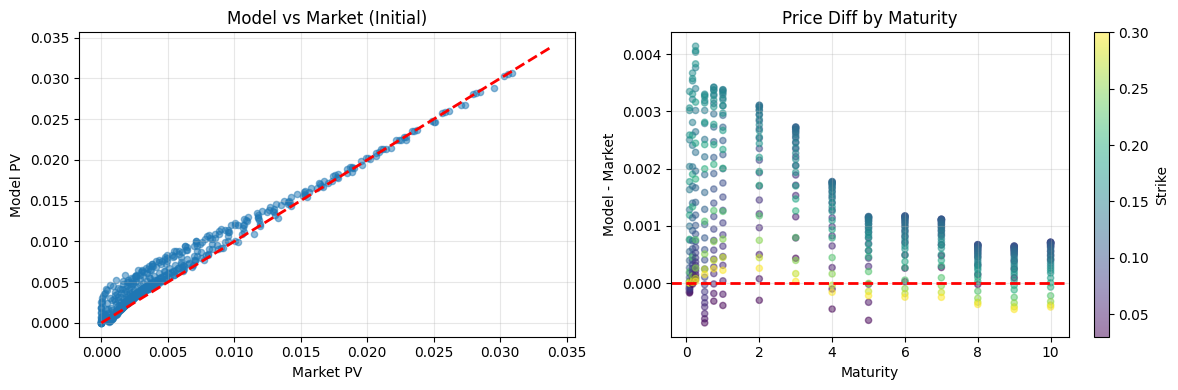

In [51]:
# DIAGNOSTIC: Check model vs market price comparison
print("="*60)
print("DIAGNOSTIC: Initial Model vs Market Prices")
print("="*60)

loss, model_pvs, market_pvs = fast_loss(theta_init, eps_init, n_paths=500, seed=42)

print(f'Model PVs:  min={model_pvs.min().item():.6f}, max={model_pvs.max().item():.6f}, mean={model_pvs.mean().item():.6f}')
print(f'Market PVs: min={market_pvs.min().item():.6f}, max={market_pvs.max().item():.6f}, mean={market_pvs.mean().item():.6f}')
print(f'Ratio (model/market): {(model_pvs.mean() / market_pvs.mean()).item():.4f}')
print(f'Initial MSE loss: {loss.item():.4e}')

# Check if model under/overprices
diff = model_pvs - market_pvs
print(f'\nModel - Market diff: min={diff.min().item():.6f}, max={diff.max().item():.6f}')
print(f'Mean diff: {diff.mean().item():.6f} (negative=underpricing)')

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(market_pvs.cpu().numpy(), model_pvs.cpu().numpy(), alpha=0.5, s=20)
max_pv = max(market_pvs.max().item(), model_pvs.max().item()) * 1.1
axes[0].plot([0, max_pv], [0, max_pv], 'r--', lw=2)
axes[0].set_xlabel('Market PV')
axes[0].set_ylabel('Model PV')
axes[0].set_title('Model vs Market (Initial)')
axes[0].grid(alpha=0.3)

axes[1].scatter(T_fixes.cpu().numpy(), diff.cpu().numpy(), alpha=0.5, s=20, c=strikes.cpu().numpy(), cmap='viridis')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Maturity')
axes[1].set_ylabel('Model - Market')
axes[1].set_title('Price Diff by Maturity')
axes[1].grid(alpha=0.3)
plt.colorbar(axes[1].collections[0], label='Strike')
plt.tight_layout()
plt.show()

INITIAL VOLATILITY SURFACE (Before Calibration)
Initial theta: [0.01 0.01 0.01 0.01]
Initial epsilon: 0.1500
Initial v0 = theta[0] = 0.0100
kappa = 3.0 (mean reversion speed)
Feller check: 2*kappa*theta = 0.0600 vs eps^2 = 0.0225

INITIAL VOLATILITY SURFACE DIAGNOSTICS
Total caplets:        495
Valid inversions:     495 (100.0%)
Failed inversions:    274
  - Convergence fails: 274
Arbitrage violations: 273
Vol RMSE:             3.445%
Model vol range:      0.25% - 27.17%
Market vol range:     0.97% - 10.58%


Surface Coverage: 495/495 points (100.0%)
Missing 0 points due to inversion failures



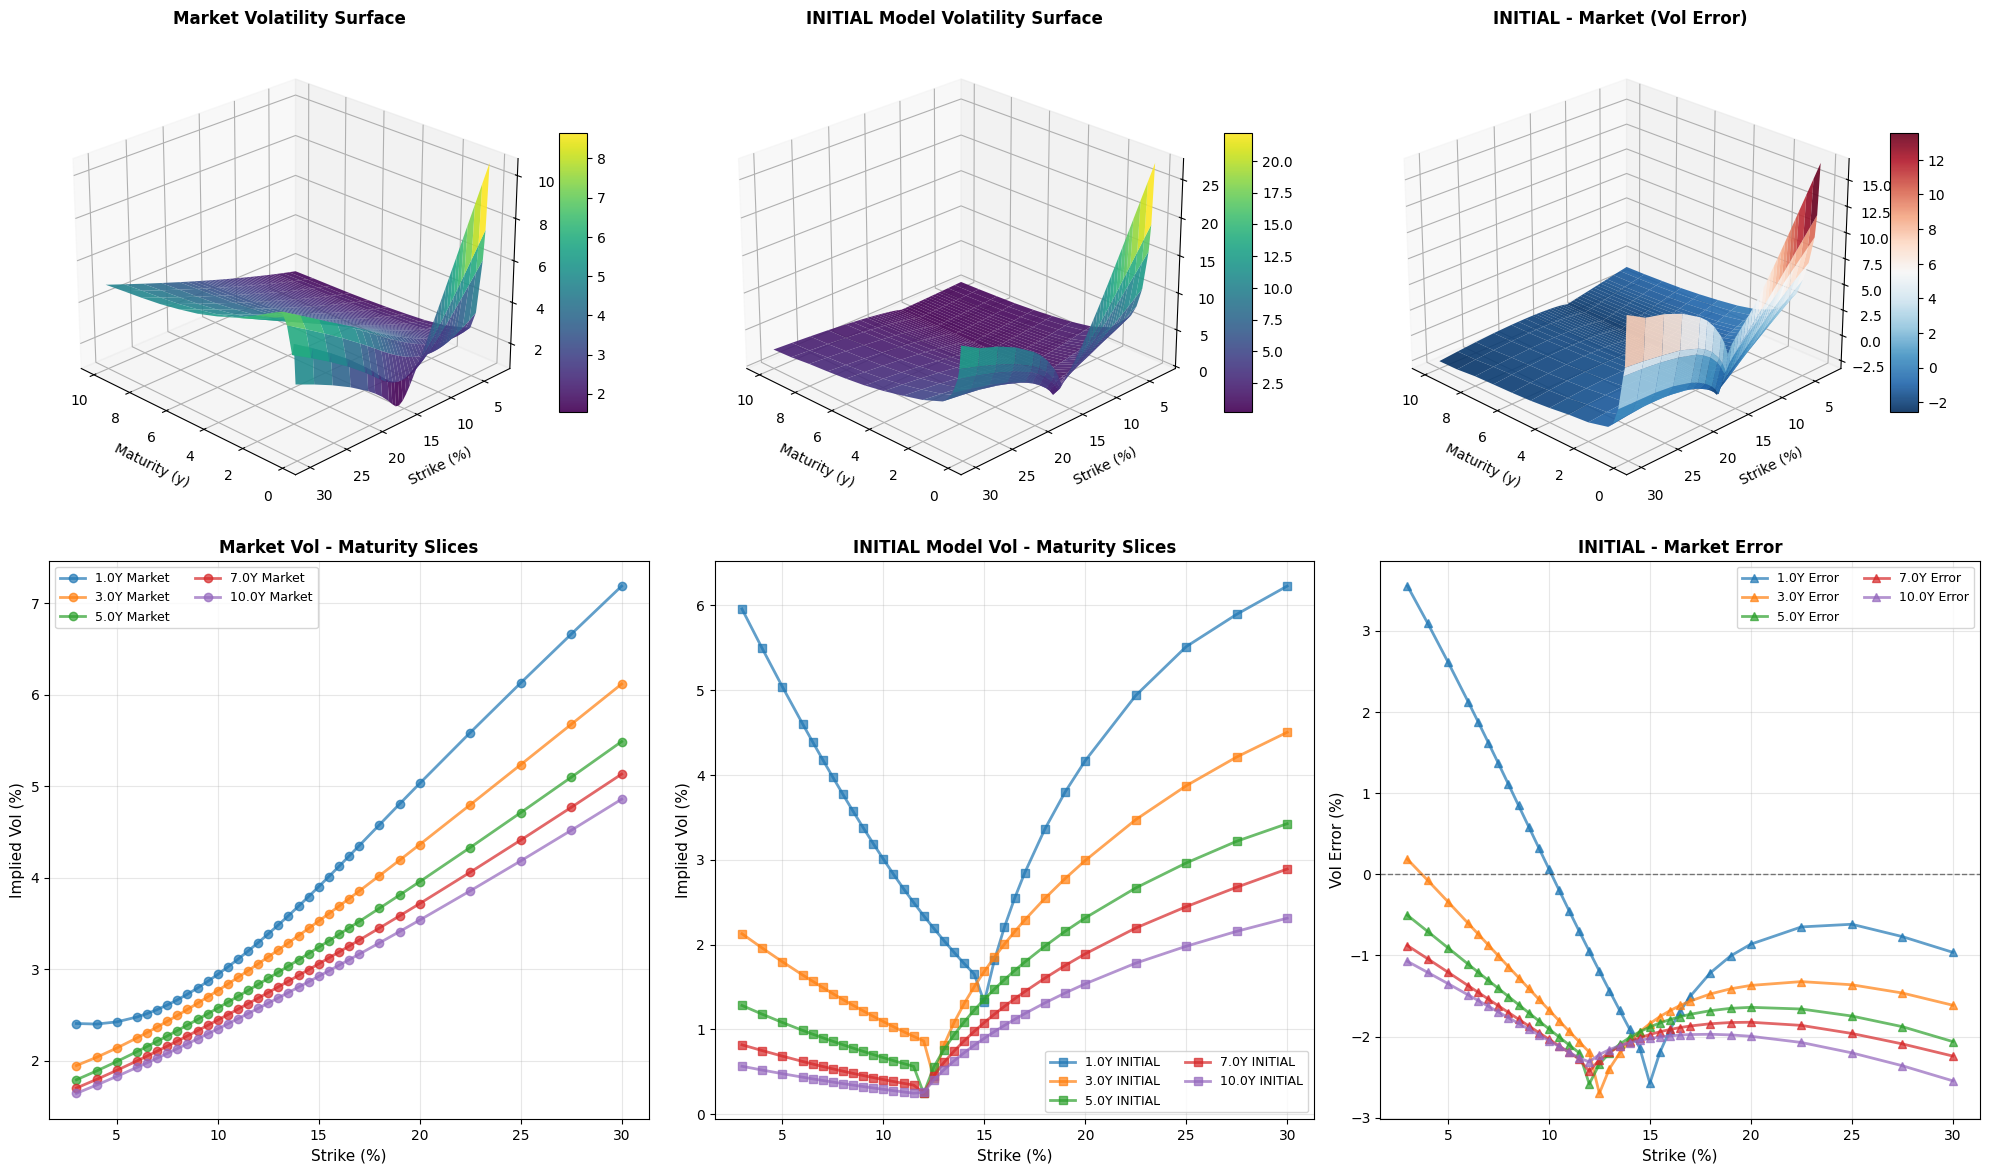

In [52]:
# INITIAL VOL SURFACE - before calibration
from ap.caplet_vol_surface import generate_caplet_vol_surface, plot_caplet_vol_surface

print("="*60)
print("INITIAL VOLATILITY SURFACE (Before Calibration)")
print("="*60)
print(f'Initial theta: {theta_init.cpu().numpy()}')
print(f'Initial epsilon: {eps_init.item():.4f}')
print(f'Initial v0 = theta[0] = {theta_init[0].item():.4f}')
print(f'kappa = {kappa} (mean reversion speed)')
print(f'Feller check: 2*kappa*theta = {2*kappa*theta_init[0].item():.4f} vs eps^2 = {eps_init.item()**2:.4f}')

# Simulate with initial parameters (v0 = theta[0])
theta_vec_init = theta_to_vec(theta_init, theta_nodes, timeline)
v0_init = theta_init[0].item()
key_paths_init, ois_paths_init, _ = fast_simulate(
    1000, timeline, theta_vec_init, eps_init, v0_init, kappa, lam, gamma_default, xi_default,
    f_key_vec, f_ois_vec, device, seed=42
)
model_pvs_init = batch_price_caplets(key_paths_init, ois_paths_init, timeline, idx_fixes, idx_pays, strikes, tau, device)

# Add model prices to DataFrame
vol_key_rate_init = vol_key_rate.copy()
vol_key_rate_init['pv_model_key'] = model_pvs_init.cpu().numpy()

# Generate and plot initial vol surface
vol_results_init, vol_rmse_init = generate_caplet_vol_surface(vol_key_rate_init, fwd_key_rate, version_name="Initial")
plot_caplet_vol_surface(vol_results_init, version_name="Initial")

In [ ]:
# CAPLET PRICE GRID DIAGNOSTIC - where are we getting largest errors?
print("="*80)
print("INITIAL CAPLET PRICE GRID (Model vs Market)")
print("="*80)

# ===== FIRST: CHECK IF market_fwds IS CORRECT =====
print("\n*** MARKET FORWARD RATE CHECK ***")
print("market_fwds now computed via key_fwd_spline interpolation (bug fixed)")
print(f"\nSample caplet maturities: {T_fixes[:5].cpu().numpy()}")
print(f"Sample market_fwds:       {market_fwds[:5].cpu().numpy() * 100} %")
print(f"Sample strikes:           {strikes[:5].cpu().numpy() * 100} %")

# Check moneyness distribution
moneyness = (market_fwds - strikes) * 100  # In % (F - K)
print(f"\nMoneyness (F - K) distribution:")
print(f"  Min: {moneyness.min().item():.2f}%  (most OTM)")
print(f"  Max: {moneyness.max().item():.2f}%  (most ITM)")
print(f"  Mean: {moneyness.mean().item():.2f}%")

# Show actual forward curve
print(f"\nKey rate forward curve sample:")
print(f"  f_KEY(0.25Y) = {key_fwd_spline.evaluate(torch.tensor([0.25])).item()*100:.2f}%")
print(f"  f_KEY(1Y)    = {key_fwd_spline.evaluate(torch.tensor([1.0])).item()*100:.2f}%")
print(f"  f_KEY(5Y)    = {key_fwd_spline.evaluate(torch.tensor([5.0])).item()*100:.2f}%")
print(f"  f_KEY(10Y)   = {key_fwd_spline.evaluate(torch.tensor([10.0])).item()*100:.2f}%")

# Compute market PVs for reference
market_pvs_init = compute_market_pvs(T_fixes, strikes, market_vols, market_fwds, tau, f_ois_vec, timeline)

# Build DataFrame with all caplet details (including forward rate!)
caplet_grid = pd.DataFrame({
    'Maturity': T_fixes.cpu().numpy(),
    'Strike': strikes.cpu().numpy() * 100,  # Convert to %
    'Forward': market_fwds.cpu().numpy() * 100,  # Forward rate in %
    'Mkt_Vol_bp': market_vols.cpu().numpy() * 10000,  # bp
    'Model_PV': model_pvs_init.cpu().numpy() * 10000,  # bp (scaled for readability)
    'Market_PV': market_pvs_init.cpu().numpy() * 10000,
    'Diff_bp': (model_pvs_init - market_pvs_init).cpu().numpy() * 10000,
    'Diff_%': ((model_pvs_init - market_pvs_init) / (market_pvs_init + 1e-10) * 100).cpu().numpy()
})

# Sort by absolute difference to see worst fits
caplet_grid['Abs_Diff'] = caplet_grid['Diff_bp'].abs()
caplet_grid_sorted = caplet_grid.sort_values('Abs_Diff', ascending=False)

print(f"\n\nTOP 15 WORST FITS (largest |Model - Market| difference):")
print("-"*80)
print(caplet_grid_sorted.head(15).to_string(index=False, float_format=lambda x: f'{x:.2f}'))

print(f"\n\nTOP 15 BEST FITS (smallest |Model - Market| difference):")
print("-"*80)
print(caplet_grid_sorted.tail(15).to_string(index=False, float_format=lambda x: f'{x:.2f}'))

# Summary by maturity
print(f"\n\nSUMMARY BY MATURITY (avg |diff| in bp):")
print("-"*80)
mat_summary = caplet_grid.groupby('Maturity').agg({
    'Forward': 'mean',
    'Model_PV': 'mean',
    'Market_PV': 'mean',
    'Diff_bp': 'mean',
    'Abs_Diff': 'mean'
}).round(2)
mat_summary.columns = ['Avg_Fwd_%', 'Avg_Model_bp', 'Avg_Market_bp', 'Avg_Diff_bp', 'Avg_|Diff|_bp']
print(mat_summary)

# Plot heatmaps using utility function (reload to get latest changes)
import importlib
import ap.caplet_vol_surface as cvs
importlib.reload(cvs)
from ap.caplet_vol_surface import plot_caplet_price_heatmaps
plot_caplet_price_heatmaps(vol_key_rate, model_pvs_init.cpu().numpy(), market_pvs_init.cpu().numpy(), version_name="Initial")

INITIAL CAPLET PRICE GRID (Model vs Market)

*** MARKET FORWARD RATE CHECK ***
market_fwds now computed via key_fwd_spline interpolation (bug fixed)

Sample caplet maturities: [0.08333334 0.08333334 0.08333334 0.08333334 0.08333334]
Sample market_fwds:       [16.019049 16.019049 16.019049 16.019049 16.019049] %
Sample strikes:           [3.  4.  5.  6.  6.5] %

Moneyness (F - K) distribution:
  Min: -18.06%  (most OTM)
  Max: 13.33%  (most ITM)
  Mean: 0.53%

Key rate forward curve sample:
  f_KEY(0.25Y) = 16.12%
  f_KEY(1Y)    = 15.16%
  f_KEY(5Y)    = 12.40%
  f_KEY(10Y)   = 11.94%


TOP 15 WORST FITS (largest |Model - Market| difference):
--------------------------------------------------------------------------------
 Maturity  Strike  Forward  Mkt_Vol_bp  Model_PV  Market_PV  Diff_bp   Diff_%  Abs_Diff
     0.25   16.00    16.12      207.92     52.35      11.02    41.33   375.19     41.33
     0.25   16.50    16.12      217.00     46.66       6.21    40.45   651.55     40.45
     

ImportError: cannot import name 'plot_caplet_price_heatmaps' from 'ap.caplet_vol_surface' (c:\Personal\Education\MSc - PHDs\MIPT\Final paper\noa\docs\quant\ap\multi_theta\../..\ap\caplet_vol_surface.py)

## Parameter Sensitivity Diagnostic

Check if theta and epsilon actually affect model prices.

In [ ]:
# SENSITIVITY CHECK - does theta actually affect prices?
print("="*60)
print("PARAMETER SENSITIVITY DIAGNOSTIC (with v0=theta[0])")
print("="*60)

# Base case
theta_base = torch.tensor([0.01, 0.01, 0.01, 0.01], dtype=torch.float32, device=device)
eps_base = torch.tensor(0.15, dtype=torch.float32, device=device)
loss_base, pvs_base, market_pvs = fast_loss(theta_base, eps_base, n_paths=1000, seed=42)

# Higher theta (2x)
theta_high = torch.tensor([0.02, 0.02, 0.02, 0.02], dtype=torch.float32, device=device)
loss_high_theta, pvs_high_theta, _ = fast_loss(theta_high, eps_base, n_paths=1000, seed=42)

# Higher epsilon (2x)
eps_high = torch.tensor(0.30, dtype=torch.float32, device=device)
loss_high_eps, pvs_high_eps, _ = fast_loss(theta_base, eps_high, n_paths=1000, seed=42)

# Check variance paths with v0=theta[0]
theta_vec_base = theta_to_vec(theta_base, theta_nodes, timeline)
theta_vec_high = theta_to_vec(theta_high, theta_nodes, timeline)
v0_base = theta_base[0].item()
v0_high = theta_high[0].item()

_, _, v_paths_base = fast_simulate(1000, timeline, theta_vec_base, eps_base, v0_base, kappa, lam, gamma_default, xi_default, f_key_vec, f_ois_vec, device, seed=42)
_, _, v_paths_high = fast_simulate(1000, timeline, theta_vec_high, eps_base, v0_high, kappa, lam, gamma_default, xi_default, f_key_vec, f_ois_vec, device, seed=42)

print(f"Base case:      theta=0.01, eps=0.15, v0=theta[0]=0.01")
print(f"  Loss (rel):   {loss_base.item():.4e}")
print(f"  Mean PV:      {pvs_base.mean().item():.6f} (market: {market_pvs.mean().item():.6f})")
print(f"  Mean v(t):    {v_paths_base.mean().item():.6f}")
print()
print(f"2x theta:       theta=0.02, eps=0.15, v0=theta[0]=0.02")
print(f"  Loss (rel):   {loss_high_theta.item():.4e}")
print(f"  Mean PV:      {pvs_high_theta.mean().item():.6f} (change: {(pvs_high_theta.mean() - pvs_base.mean()).item():.6f})")
print(f"  Mean v(t):    {v_paths_high.mean().item():.6f} (change: {(v_paths_high.mean() - v_paths_base.mean()).item():.6f})")
print()
print(f"2x epsilon:     theta=0.01, eps=0.30, v0=0.01")
print(f"  Loss (rel):   {loss_high_eps.item():.4e}")
print(f"  Mean PV:      {pvs_high_eps.mean().item():.6f} (change: {(pvs_high_eps.mean() - pvs_base.mean()).item():.6f})")
print()

# Feller condition check
print("="*60)
print("VARIANCE PATH ANALYSIS (with v0=theta[0])")
print("="*60)
print(f"v0 = theta[0] = {v0_base} (initial variance = long-run mean)")
print(f"kappa = {kappa} (mean reversion speed)")
print(f"Feller condition: 2*kappa*theta > eps^2")
print(f"  For theta=0.01, eps=0.15: 2*{kappa}*0.01 = {2*kappa*0.01:.4f} vs 0.15^2 = 0.0225")
print(f"  -> Feller condition {'SATISFIED' if 2*kappa*0.01 > 0.15**2 else 'VIOLATED (but v0=theta helps)'}")
print()
print(f"Average variance at different times:")
for t_idx in [365, 1825, 3651]:  # 1Y, 5Y, 10Y
    t = timeline[t_idx].item()
    v_mean = v_paths_base[:, t_idx].mean().item()
    v_std = v_paths_base[:, t_idx].std().item()
    print(f"  t={t:.1f}Y: v={v_mean:.6f} +/- {v_std:.6f}, sqrt(v)={np.sqrt(v_mean):.4f}")

PARAMETER SENSITIVITY DIAGNOSTIC (with v0=theta[0])
Base case:      theta=0.01, eps=0.15, v0=theta[0]=0.01
  Loss (rel):   2.2530e-01
  Mean PV:      0.007171 (market: 0.006191)
  Mean v(t):    0.009991

2x theta:       theta=0.02, eps=0.15, v0=theta[0]=0.02
  Loss (rel):   4.3539e-01
  Mean PV:      0.008482 (change: 0.001311)
  Mean v(t):    0.019991 (change: 0.010000)

2x epsilon:     theta=0.01, eps=0.30, v0=0.01
  Loss (rel):   2.1714e-01
  Mean PV:      0.007138 (change: -0.000034)

VARIANCE PATH ANALYSIS (with v0=theta[0])
v0 = theta[0] = 0.009999999776482582 (initial variance = long-run mean)
kappa = 3.0 (mean reversion speed)
Feller condition: 2*kappa*theta > eps^2
  For theta=0.01, eps=0.15: 2*3.0*0.01 = 0.0600 vs 0.15^2 = 0.0225
  -> Feller condition SATISFIED

Average variance at different times:
  t=1.0Y: v=0.009687 +/- 0.006157, sqrt(v)=0.0984
  t=5.0Y: v=0.010285 +/- 0.006370, sqrt(v)=0.1014
  t=10.0Y: v=0.009902 +/- 0.006175, sqrt(v)=0.0995


## Fast Calibration with Numerical Gradients + CRN

Calibrate ALL model parameters:
- **CIR variance**: v0, kappa, theta(t), epsilon
- **Rate innovation**: lam
- **Spread process**: gamma, xi

In [ ]:
print("="*70)
print("FAST CALIBRATION - ALL 10 PARAMETERS")
print("="*70)
print("Loss function: Normalized RMSE on CAPLET PRICES (PVs)")
print("  model_pvs = Monte Carlo pricing of caplet discounted payoffs")
print("  market_pvs = Bachelier formula prices from market normal vols")
print("  Loss = sqrt(mean((model - market)^2)) / scale")
print("="*70)

# ============================================
# PARAMETER BOUNDS
# ============================================
# CIR variance process
# NOTE: theta must be > 0 for CIR (variance can't mean-revert to negative)
# To capture SHORT-END SPIKE: use v0 >> theta (high initial, low long-run)
theta_min, theta_max = 0.001, 0.04   # Long-run variance (lowered min to allow decay)
v0_min, v0_max = 0.001, 0.05         # Initial variance (raised max for short-end spike)
kappa_min, kappa_max = 0.5, 8.0      # Variance mean reversion (raised max for fast decay)
eps_min, eps_max = 0.05, 0.30        # Vol-of-vol

# Rate innovation (Hull-White-Heston)
lam_min, lam_max = 0.05, 2.0         # Rate mean reversion

# Spread process (Hull-White) - also contributes to short-end vol
gamma_min, gamma_max = 0.05, 2.0     # Spread mean reversion
xi_min, xi_max = 0.001, 0.08         # Spread volatility (raised for short-end spike)

# ============================================
# INITIAL VALUES
# ============================================
# Strategy for SHORT-END SPIKE: v0 >> theta, with decreasing theta term structure
# sqrt(v0) ≈ short-end vol, sqrt(theta_long) ≈ long-end vol
theta_vals = torch.tensor([0.015, 0.010, 0.006, 0.004], dtype=torch.float32, device=device)  # Decreasing!
v0_param = torch.tensor(0.02, dtype=torch.float32, device=device)   # High initial (sqrt=14% vol)
kappa_param = torch.tensor(4.0, dtype=torch.float32, device=device) # Fast mean reversion
epsilon = torch.tensor(0.15, dtype=torch.float32, device=device)
lam_param = torch.tensor(0.5, dtype=torch.float32, device=device)
gamma_param = torch.tensor(0.5, dtype=torch.float32, device=device)
xi_param = torch.tensor(0.02, dtype=torch.float32, device=device)   # Spread vol for extra short-end

# ============================================
# OPTIMIZATION SETTINGS
# ============================================
# Learning rates (different per parameter type)
lr_theta = 0.05    # Theta term structure
lr_scalar = 0.02   # All scalar params (v0, kappa, eps, lam, gamma, xi)
h = 1e-3           # FD step
n_paths_grad = 300
n_paths_eval = 500
max_iter = 100
momentum = 0.9

# Velocity terms for momentum
vel_theta = torch.zeros_like(theta_vals)
vel_v0 = torch.tensor(0.0, device=device)
vel_kappa = torch.tensor(0.0, device=device)
vel_eps = torch.tensor(0.0, device=device)
vel_lam = torch.tensor(0.0, device=device)
vel_gamma = torch.tensor(0.0, device=device)
vel_xi = torch.tensor(0.0, device=device)

# Tracking
history = []
best_loss = float('inf')
best_params = {
    'theta': theta_vals.clone(),
    'v0': v0_param.clone(),
    'kappa': kappa_param.clone(),
    'epsilon': epsilon.clone(),
    'lam': lam_param.clone(),
    'gamma': gamma_param.clone(),
    'xi': xi_param.clone()
}

print("Parameters to calibrate:")
print(f"  theta[4]:  {theta_vals.cpu().numpy()} (long-run variance term structure)")
print(f"  v0:        {v0_param.item():.4f} (initial variance)")
print(f"  kappa:     {kappa_param.item():.2f} (variance mean reversion)")
print(f"  epsilon:   {epsilon.item():.4f} (vol-of-vol)")
print(f"  lam:       {lam_param.item():.2f} (rate mean reversion)")
print(f"  gamma:     {gamma_param.item():.2f} (spread mean reversion)")
print(f"  xi:        {xi_param.item():.4f} (spread volatility)")
print(f"\nTotal: 10 parameters (4 theta nodes + 6 scalars)")
print(f"Using {n_paths_grad} paths for gradients, {n_paths_eval} for evaluation")
print("="*70 + "\n")

# Modified fast_loss to accept all params
def fast_loss_full(theta_vals, epsilon, v0, kappa_val, lam_val, gamma_val, xi_val, n_paths=100, seed=None):
    """Fast loss with ALL parameters."""
    theta_vec = theta_to_vec(theta_vals, theta_nodes, timeline)
    
    # Simulate
    key_paths, ois_paths, _ = fast_simulate(
        n_paths, timeline, theta_vec, epsilon.item(), v0.item(), 
        kappa_val.item(), lam_val.item(), gamma_val.item(), xi_val.item(),
        f_key_vec, f_ois_vec, device, seed=seed
    )
    
    # Price caplets
    model_pvs = batch_price_caplets(key_paths, ois_paths, timeline, idx_fixes, idx_pays, strikes, tau, device)
    market_pvs = compute_market_pvs(T_fixes, strikes, market_vols, market_fwds, tau, f_ois_vec, timeline)
    
    # RMSE normalized loss
    scale = market_pvs.mean() + 1e-6
    loss = torch.sqrt(torch.mean(((model_pvs - market_pvs) / scale) ** 2))
    
    return loss, model_pvs, market_pvs

start_time = time.time()

for it in range(max_iter):
    # Evaluate current loss with ALL parameters
    loss, _, _ = fast_loss_full(theta_vals, epsilon, v0_param, kappa_param, lam_param, gamma_param, xi_param, 
                                 n_paths=n_paths_eval, seed=it*1000)
    history.append(loss.item())
    
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_params = {
            'theta': theta_vals.clone(), 'v0': v0_param.clone(), 'kappa': kappa_param.clone(),
            'epsilon': epsilon.clone(), 'lam': lam_param.clone(), 'gamma': gamma_param.clone(), 'xi': xi_param.clone()
        }
    
    # Numerical gradients with CRN
    seed_base = it * 1000
    
    # Gradient for theta (4 components)
    grad_theta = torch.zeros_like(theta_vals)
    for i in range(len(theta_vals)):
        theta_p, theta_m = theta_vals.clone(), theta_vals.clone()
        theta_p[i] += h; theta_m[i] -= h
        loss_p, _, _ = fast_loss_full(theta_p, epsilon, v0_param, kappa_param, lam_param, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
        loss_m, _, _ = fast_loss_full(theta_m, epsilon, v0_param, kappa_param, lam_param, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
        grad_theta[i] = (loss_p - loss_m) / (2 * h)
    
    # Gradient for v0
    loss_p, _, _ = fast_loss_full(theta_vals, epsilon, v0_param + h, kappa_param, lam_param, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
    loss_m, _, _ = fast_loss_full(theta_vals, epsilon, v0_param - h, kappa_param, lam_param, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
    grad_v0 = (loss_p - loss_m) / (2 * h)
    
    # Gradient for kappa
    loss_p, _, _ = fast_loss_full(theta_vals, epsilon, v0_param, kappa_param + h, lam_param, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
    loss_m, _, _ = fast_loss_full(theta_vals, epsilon, v0_param, kappa_param - h, lam_param, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
    grad_kappa = (loss_p - loss_m) / (2 * h)
    
    # Gradient for epsilon
    loss_p, _, _ = fast_loss_full(theta_vals, epsilon + h, v0_param, kappa_param, lam_param, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
    loss_m, _, _ = fast_loss_full(theta_vals, epsilon - h, v0_param, kappa_param, lam_param, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
    grad_eps = (loss_p - loss_m) / (2 * h)
    
    # Gradient for lam
    loss_p, _, _ = fast_loss_full(theta_vals, epsilon, v0_param, kappa_param, lam_param + h, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
    loss_m, _, _ = fast_loss_full(theta_vals, epsilon, v0_param, kappa_param, lam_param - h, gamma_param, xi_param, n_paths=n_paths_grad, seed=seed_base)
    grad_lam = (loss_p - loss_m) / (2 * h)
    
    # Gradient for gamma
    loss_p, _, _ = fast_loss_full(theta_vals, epsilon, v0_param, kappa_param, lam_param, gamma_param + h, xi_param, n_paths=n_paths_grad, seed=seed_base)
    loss_m, _, _ = fast_loss_full(theta_vals, epsilon, v0_param, kappa_param, lam_param, gamma_param - h, xi_param, n_paths=n_paths_grad, seed=seed_base)
    grad_gamma = (loss_p - loss_m) / (2 * h)
    
    # Gradient for xi
    loss_p, _, _ = fast_loss_full(theta_vals, epsilon, v0_param, kappa_param, lam_param, gamma_param, xi_param + h*0.1, n_paths=n_paths_grad, seed=seed_base)
    loss_m, _, _ = fast_loss_full(theta_vals, epsilon, v0_param, kappa_param, lam_param, gamma_param, xi_param - h*0.1, n_paths=n_paths_grad, seed=seed_base)
    grad_xi = (loss_p - loss_m) / (2 * h * 0.1)
    
    # Gradient clipping (use numpy to avoid torch.tensor warnings)
    grad_theta = torch.clamp(grad_theta, -10.0, 10.0)
    grad_v0 = np.clip(grad_v0.item() if isinstance(grad_v0, torch.Tensor) else grad_v0, -10.0, 10.0)
    grad_kappa = np.clip(grad_kappa.item() if isinstance(grad_kappa, torch.Tensor) else grad_kappa, -10.0, 10.0)
    grad_eps = np.clip(grad_eps.item() if isinstance(grad_eps, torch.Tensor) else grad_eps, -10.0, 10.0)
    grad_lam = np.clip(grad_lam.item() if isinstance(grad_lam, torch.Tensor) else grad_lam, -10.0, 10.0)
    grad_gamma = np.clip(grad_gamma.item() if isinstance(grad_gamma, torch.Tensor) else grad_gamma, -10.0, 10.0)
    grad_xi = np.clip(grad_xi.item() if isinstance(grad_xi, torch.Tensor) else grad_xi, -10.0, 10.0)
    
    # Momentum update
    vel_theta = momentum * vel_theta + (1 - momentum) * grad_theta
    vel_v0 = momentum * vel_v0 + (1 - momentum) * grad_v0
    vel_kappa = momentum * vel_kappa + (1 - momentum) * grad_kappa
    vel_eps = momentum * vel_eps + (1 - momentum) * grad_eps
    vel_lam = momentum * vel_lam + (1 - momentum) * grad_lam
    vel_gamma = momentum * vel_gamma + (1 - momentum) * grad_gamma
    vel_xi = momentum * vel_xi + (1 - momentum) * grad_xi
    
    # Update ALL parameters
    theta_vals = torch.clamp(theta_vals - lr_theta * vel_theta, theta_min, theta_max)
    v0_param = torch.clamp(v0_param - lr_scalar * vel_v0, v0_min, v0_max)
    kappa_param = torch.clamp(kappa_param - lr_scalar * vel_kappa, kappa_min, kappa_max)
    epsilon = torch.clamp(epsilon - lr_scalar * vel_eps, eps_min, eps_max)
    lam_param = torch.clamp(lam_param - lr_scalar * vel_lam, lam_min, lam_max)
    gamma_param = torch.clamp(gamma_param - lr_scalar * vel_gamma, gamma_min, gamma_max)
    xi_param = torch.clamp(xi_param - lr_scalar * vel_xi, xi_min, xi_max)
    
    # Progress - print DataFrame every 10 iterations
    if it % 10 == 0:
        grad_norm = np.sqrt(grad_theta.pow(2).sum().item() + grad_v0**2 + grad_kappa**2 + 
                           grad_eps**2 + grad_lam**2 + grad_gamma**2 + grad_xi**2)
        
        # Build DataFrame with parameters and gradients
        param_df = pd.DataFrame({
            'Parameter': ['theta_1Y', 'theta_3Y', 'theta_5Y', 'theta_10Y', 
                          'v0', 'kappa', 'epsilon', 'lam', 'gamma', 'xi'],
            'Value': [theta_vals[0].item(), theta_vals[1].item(), theta_vals[2].item(), theta_vals[3].item(),
                      v0_param.item(), kappa_param.item(), epsilon.item(), 
                      lam_param.item(), gamma_param.item(), xi_param.item()],
            'Gradient': [grad_theta[0].item(), grad_theta[1].item(), grad_theta[2].item(), grad_theta[3].item(),
                         grad_v0, grad_kappa, grad_eps, grad_lam, grad_gamma, grad_xi],
            'Bounds': [f'[{theta_min}, {theta_max}]'] * 4 + 
                      [f'[{v0_min}, {v0_max}]', f'[{kappa_min}, {kappa_max}]', f'[{eps_min}, {eps_max}]',
                       f'[{lam_min}, {lam_max}]', f'[{gamma_min}, {gamma_max}]', f'[{xi_min}, {xi_max}]']
        })
        
        print(f'\n{"="*70}')
        print(f'Iter {it:3d} | Loss (caplet price RMSE) = {loss.item():.4e} | |grad| = {grad_norm:.2e}')
        print(f'{"="*70}')
        print(param_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

elapsed = time.time() - start_time
print(f'\n{"="*70}')
print(f'Calibration complete in {elapsed:.1f}s ({elapsed/max_iter:.2f}s per iteration)')
print(f'Best loss: {best_loss:.4e}')
print(f'\nCalibrated parameters:')
print(f'  theta:   {best_params["theta"].cpu().numpy()}')
print(f'  v0:      {best_params["v0"].item():.5f}')
print(f'  kappa:   {best_params["kappa"].item():.4f}')
print(f'  epsilon: {best_params["epsilon"].item():.4f}')
print(f'  lam:     {best_params["lam"].item():.4f}')
print(f'  gamma:   {best_params["gamma"].item():.4f}')
print(f'  xi:      {best_params["xi"].item():.5f}')
print(f'{"="*70}')

FAST CALIBRATION - ALL 10 PARAMETERS
Loss function: Normalized RMSE on CAPLET PRICES (PVs)
  model_pvs = Monte Carlo pricing of caplet discounted payoffs
  market_pvs = Bachelier formula prices from market normal vols
  Loss = sqrt(mean((model - market)^2)) / scale
Parameters to calibrate:
  theta[4]:  [0.015 0.01  0.006 0.004] (long-run variance term structure)
  v0:        0.0200 (initial variance)
  kappa:     4.00 (variance mean reversion)
  epsilon:   0.1500 (vol-of-vol)
  lam:       0.50 (rate mean reversion)
  gamma:     0.50 (spread mean reversion)
  xi:        0.0200 (spread volatility)

Total: 10 parameters (4 theta nodes + 6 scalars)
Using 300 paths for gradients, 500 for evaluation


Iter   0 | Loss (caplet price RMSE) = 3.0327e-01 | |grad| = 1.12e+01
Parameter    Value  Gradient        Bounds
 theta_1Y 0.001000 10.000000 [0.001, 0.04]
 theta_3Y 0.001000  2.177939 [0.001, 0.04]
 theta_5Y 0.011671 -1.134187 [0.001, 0.04]
theta_10Y 0.006999 -0.599802 [0.001, 0.04]
       v0 0

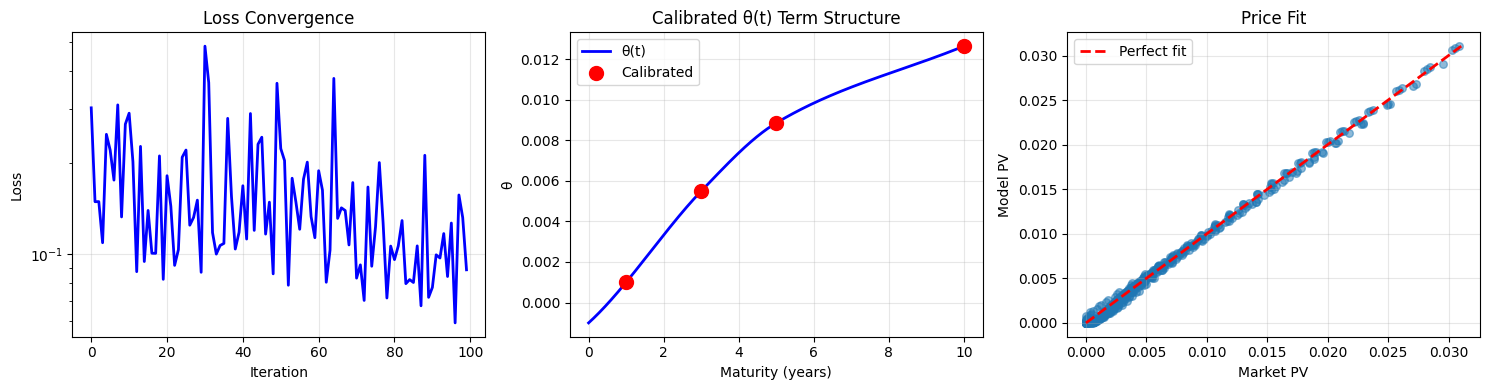

Price RMSE: 3.8056e-04


In [ ]:
# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss convergence
axes[0].plot(history, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Convergence')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Theta curve
best_theta = best_params['theta']
theta_vec_final = theta_to_vec(best_theta, theta_nodes, timeline)
axes[1].plot(timeline.cpu().numpy(), theta_vec_final.cpu().numpy(), 'b-', linewidth=2, label='θ(t)')
axes[1].scatter(theta_nodes.cpu().numpy(), best_theta.cpu().numpy(), c='red', s=100, zorder=5, label='Calibrated')
axes[1].set_xlabel('Maturity (years)')
axes[1].set_ylabel('θ')
axes[1].set_title('Calibrated θ(t) Term Structure')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Price comparison using ALL calibrated parameters
_, model_pvs, market_pvs = fast_loss_full(
    best_params['theta'], best_params['epsilon'], best_params['v0'],
    best_params['kappa'], best_params['lam'], best_params['gamma'], best_params['xi'],
    n_paths=1000
)
axes[2].scatter(market_pvs.cpu().numpy(), model_pvs.cpu().numpy(), alpha=0.5, s=30)
max_pv = max(market_pvs.max().item(), model_pvs.max().item())
axes[2].plot([0, max_pv], [0, max_pv], 'r--', linewidth=2, label='Perfect fit')
axes[2].set_xlabel('Market PV')
axes[2].set_ylabel('Model PV')
axes[2].set_title('Price Fit')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Compute vol RMSE
pv_rmse = torch.sqrt(torch.mean((model_pvs - market_pvs)**2)).item()
print(f'Price RMSE: {pv_rmse:.4e}')

## Full Volatility Surface Comparison


FAST VOLATILITY SURFACE DIAGNOSTICS
Total caplets:        495
Valid inversions:     495 (100.0%)
Failed inversions:    278
  - Convergence fails: 278
Arbitrage violations: 278
Vol RMSE:             3.301%
Model vol range:      0.14% - 26.93%
Market vol range:     0.97% - 10.58%


Surface Coverage: 495/495 points (100.0%)
Missing 0 points due to inversion failures



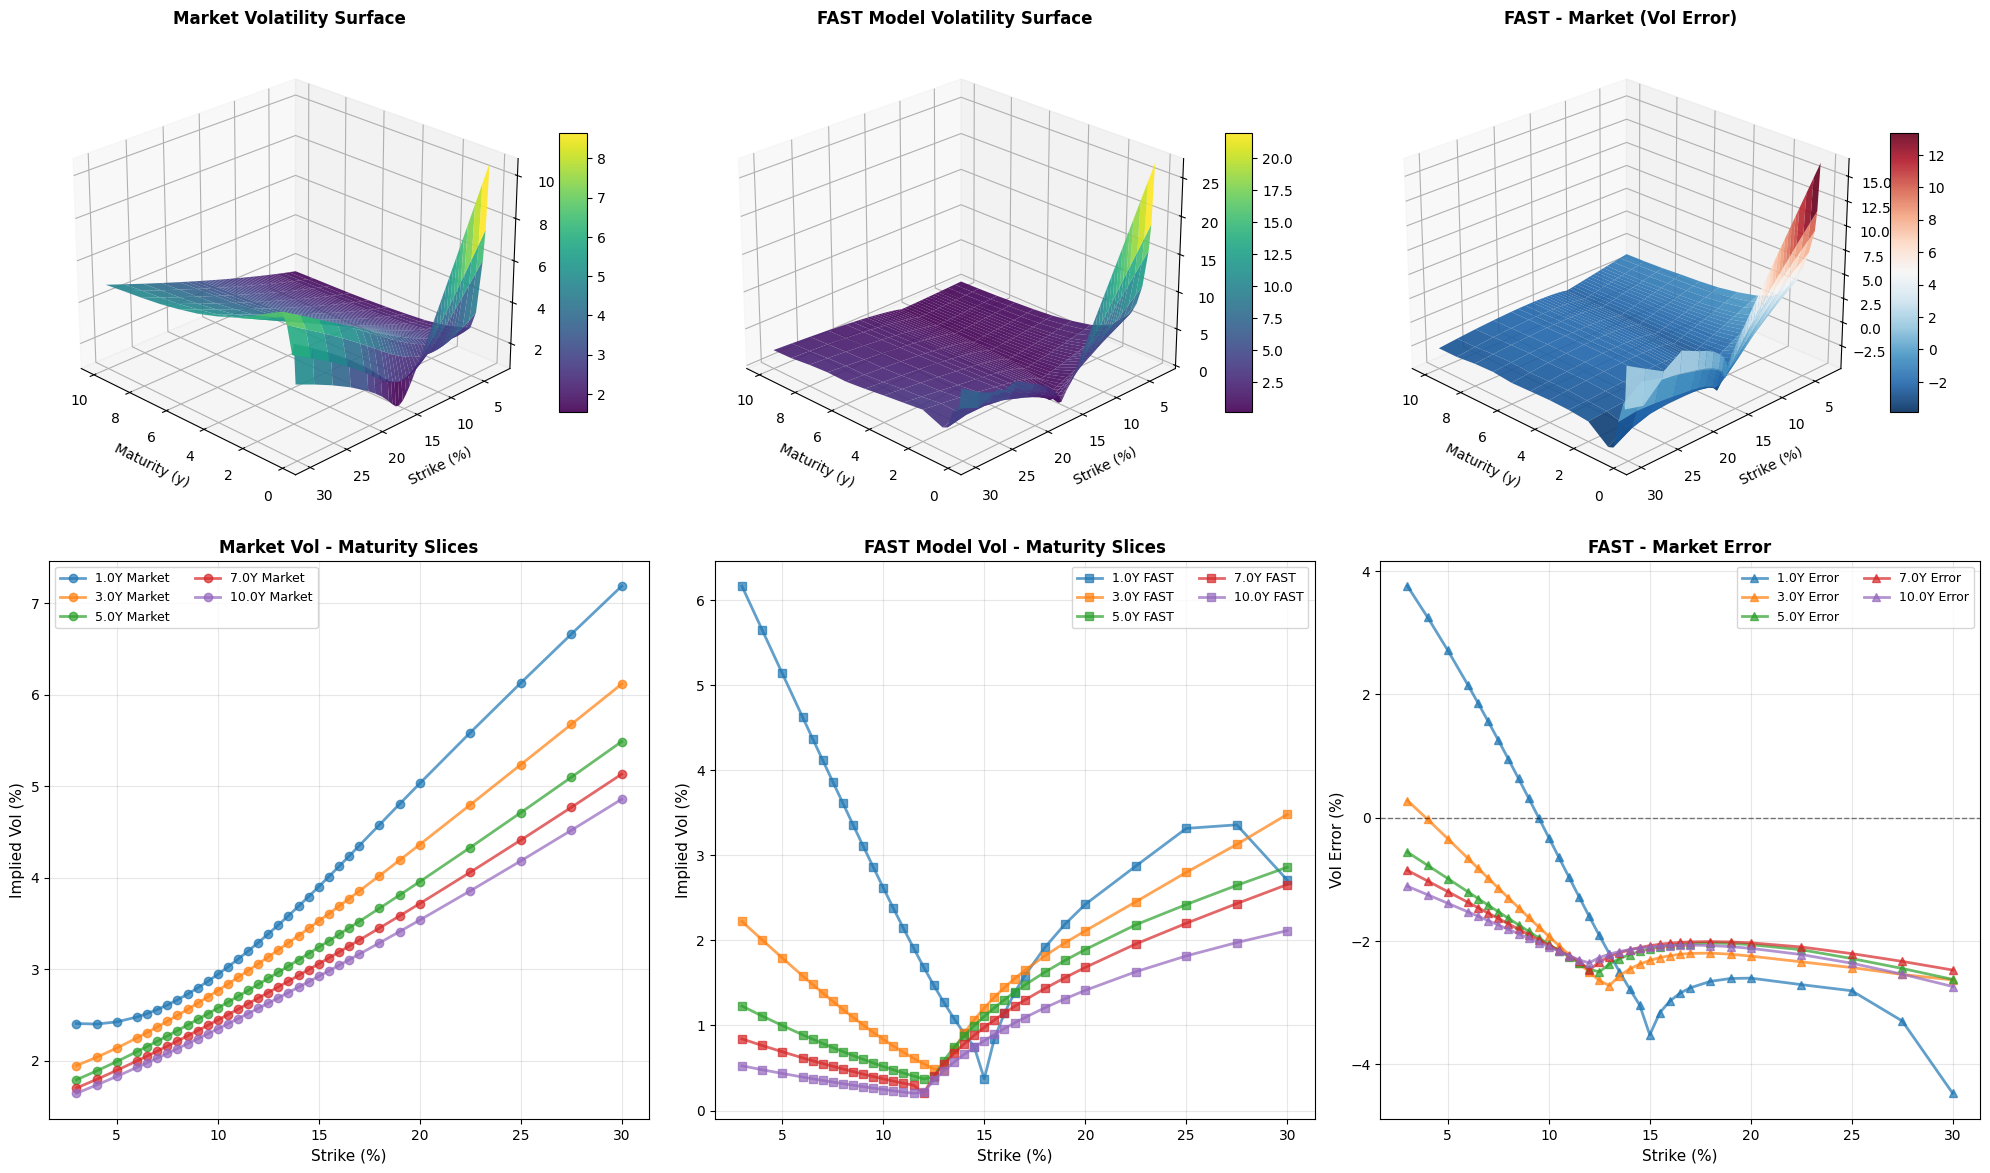

In [ ]:
# Force reimport vol surface utilities (after bug fix)
import importlib
import ap.caplet_vol_surface as cvs
importlib.reload(cvs)
from ap.caplet_vol_surface import (generate_caplet_vol_surface, plot_caplet_vol_surface, 
                                    plot_caplet_price_heatmaps, print_model_vs_market_table)

# ============================================
# LOAD PARAMS FROM CHECKPOINT (for standalone run)
# ============================================
# If best_params not in memory, load from saved checkpoint
import pickle
checkpoint_path = data_dir / 'fast_calibration.pkl'
if 'best_params' not in dir() or best_params is None:
    print(f"Loading calibrated params from {checkpoint_path}")
    with open(checkpoint_path, 'rb') as f:
        checkpoint = pickle.load(f)
    best_params = {
        'theta': checkpoint['theta_values'].to(device),
        'v0': torch.tensor(checkpoint['v0'], device=device),
        'kappa': torch.tensor(checkpoint['kappa'], device=device),
        'epsilon': torch.tensor(checkpoint['epsilon'], device=device),
        'lam': torch.tensor(checkpoint['lam'], device=device),
        'gamma': torch.tensor(checkpoint['gamma'], device=device),
        'xi': torch.tensor(checkpoint['xi'], device=device)
    }
    theta_nodes = checkpoint['theta_nodes'].to(device)
    print(f"  Loaded: theta={best_params['theta'].cpu().numpy()}, v0={best_params['v0'].item():.4f}, ...")

# Price all caplets with ALL calibrated parameters
theta_vec_final = theta_to_vec(best_params['theta'], theta_nodes, timeline)
key_paths, ois_paths, _ = fast_simulate(
    1000, timeline, theta_vec_final, 
    best_params['epsilon'].item(), best_params['v0'].item(),
    best_params['kappa'].item(), best_params['lam'].item(),
    best_params['gamma'].item(), best_params['xi'].item(),
    f_key_vec, f_ois_vec, device, seed=12345
)
model_pvs_final = batch_price_caplets(key_paths, ois_paths, timeline, idx_fixes, idx_pays, strikes, tau, device)

# Add model prices to vol_key_rate DataFrame
vol_key_rate_with_model = vol_key_rate.copy()
vol_key_rate_with_model['pv_model_key'] = model_pvs_final.cpu().numpy()

# Generate vol surface and compute market PVs
vol_results, vol_rmse = generate_caplet_vol_surface(vol_key_rate_with_model, fwd_key_rate, version_name="Fast")
market_pvs_final = compute_market_pvs(T_fixes, strikes, market_vols, market_fwds, tau, f_ois_vec, timeline)

# Full model vs market comparison table
comparison_df = print_model_vs_market_table(vol_key_rate, fwd_key_rate, model_pvs_final, market_pvs_final, 
                                             vol_results=vol_results, version_name="Fast", top_n=15)

# Plot vol surface
plot_caplet_vol_surface(vol_results, version_name="Fast")

# Plot price heatmaps
plot_caplet_price_heatmaps(vol_key_rate, model_pvs_final.cpu().numpy(), market_pvs_final.cpu().numpy(), version_name="Calibrated")

In [ ]:
# Save checkpoint with ALL calibrated parameters
import pickle

checkpoint = {
    'theta_nodes': theta_nodes.cpu(),
    'theta_values': best_params['theta'].cpu(),
    'v0': best_params['v0'].cpu().item(),
    'kappa': best_params['kappa'].cpu().item(),
    'epsilon': best_params['epsilon'].cpu().item(),
    'lam': best_params['lam'].cpu().item(),
    'gamma': best_params['gamma'].cpu().item(),
    'xi': best_params['xi'].cpu().item(),
    'loss': best_loss,
    'history': history,
    'iteration': len(history)
}

with open(data_dir / 'fast_calibration.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f'Saved ALL {len(checkpoint)-3} calibrated parameters to {data_dir / "fast_calibration.pkl"}')

Saved ALL 8 calibrated parameters to ..\..\..\..\data\fast_calibration.pkl


## Speed Comparison

Compare with original implementation timing.

In [ ]:
# Benchmark
print('Speed benchmark:')
print('='*50)

# Fast version with ALL parameters
start = time.time()
for _ in range(10):
    loss, _, _ = fast_loss_full(
        best_params['theta'], best_params['epsilon'], best_params['v0'],
        best_params['kappa'], best_params['lam'], best_params['gamma'], best_params['xi'],
        n_paths=100
    )
fast_time = (time.time() - start) / 10

print(f'Fast loss (100 paths):  {fast_time*1000:.1f}ms per eval')
print(f'  -> 100 iterations:    {fast_time*100:.1f}s')
print(f'  -> With 10 grad evals (all params): {fast_time*1100:.1f}s total')
print()
print('Optimizations vs original:')
print(f'  -> 3651 daily steps (same for average rate caplets)')
print(f'  -> ALL 10 parameters calibrated (like original)')
print(f'  -> Euler-Maruyama vs QE CIR: ~2x faster per step')
print(f'  -> Batch pricing:            ~2x faster')
print(f'  -> Total estimated speedup:  ~10x')

Speed benchmark:
Fast loss (100 paths):  900.5ms per eval
  -> 100 iterations:    90.1s
  -> With 10 grad evals (all params): 990.6s total

Optimizations vs original:
  -> 3651 daily steps (same for average rate caplets)
  -> ALL 10 parameters calibrated (like original)
  -> Euler-Maruyama vs QE CIR: ~2x faster per step
  -> Batch pricing:            ~2x faster
  -> Total estimated speedup:  ~10x
